In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [6]:
np.random.seed(42)

n = 50

df = pd.DataFrame({
    "Price_Lakhs": np.random.randint(30, 200, n),
    "Area_sqft": np.random.randint(700, 3500, n),
    "Bedrooms": np.random.randint(1, 6, n),
    "Bathrooms": np.random.randint(1, 5, n),
    "Distance_City_km": np.random.randint(1, 30, n),
    "Crime_Rate": np.random.uniform(1, 10, n),
    "School_Rating": np.random.uniform(1, 10, n),
    "Property_Age": np.random.randint(0, 40, n),
    "Days_On_Market": np.random.randint(30, 365, n)
})

print("Dataset:")
print(df.head())

Dataset:
   Price_Lakhs  Area_sqft  Bedrooms  Bathrooms  Distance_City_km  Crime_Rate  \
0          132       2063         3          2                20    8.725229   
1          122       2839         3          4                12    3.933630   
2           44       2090         1          4                 7    2.982169   
3          136       2178         3          4                 2    7.400346   
4          101       3256         5          4                 3    8.285509   

   School_Rating  Property_Age  Days_On_Market  
0       7.697535            38             156  
1       7.488459            28             158  
2       3.772547            25              87  
3       5.882862            34             151  
4       5.579327            24              30  


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)



Explained Variance Ratio:
[0.18045191 0.16614226]


In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df.columns
)

print("\nPCA Loading Matrix:")
print(loadings)


PCA Loading Matrix:
                       PC1       PC2
Price_Lakhs       0.616894 -0.117304
Area_sqft        -0.488253 -0.336361
Bedrooms          0.224892  0.139281
Bathrooms        -0.236051 -0.193314
Distance_City_km -0.306122 -0.153211
Crime_Rate        0.280005 -0.486507
School_Rating     0.281424 -0.374569
Property_Age     -0.142891  0.065504
Days_On_Market    0.054986  0.641542


In [10]:
print("\nMost Influential Variables:")

for pc in loadings.columns:
    variable = loadings[pc].abs().idxmax()
    value = loadings.loc[variable, pc]
    print(f"{pc}: {variable} (Loading = {value:.3f})")


Most Influential Variables:
PC1: Price_Lakhs (Loading = 0.617)
PC2: Days_On_Market (Loading = 0.642)


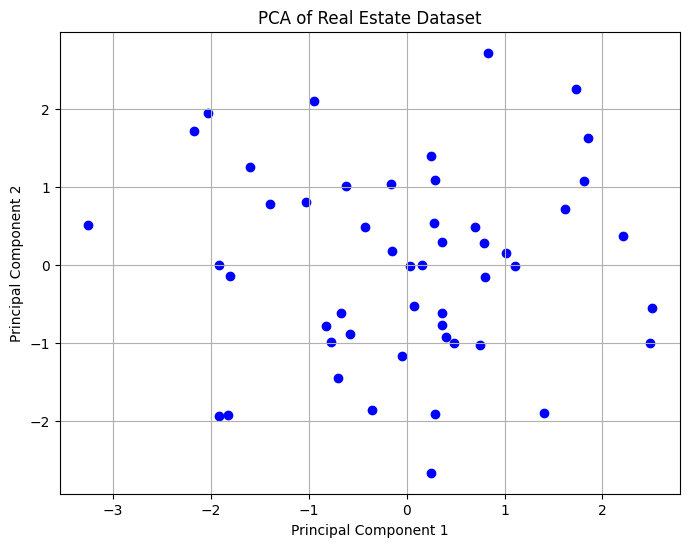

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue')

plt.title("PCA of Real Estate Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()